<a href="https://colab.research.google.com/github/IronZiiz/Machine-Learning_Classification/blob/main/NLP_review_movies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports
Exploratory of models. Understanding the problem of language processing

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
resenha = pd.read_csv("/content/drive/MyDrive/Alura/Visão computacional/NLP/imdb-reviews-pt-br.csv")

In [5]:
resenha.head()

,id,text_en,text_pt,sentiment
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg


In [6]:
from sklearn.model_selection import train_test_split

In [7]:
treino, teste, classe_treino, classe_teste = train_test_split(resenha.text_pt,
                                                              resenha.sentiment,
                                                              random_state = 42)

In [8]:
treino

,text_pt
1348,"Embora o filme tenha sido apenas assim, o clos..."
27466,Este é provavelmente um dos piores filmes que ...
29998,"De vez em quando, um filme irá varrer ao seu r..."
48186,Este é um conto completamente diabólico de quã...
26473,"Lenta, chata, extremamente repetitiva. Não adm..."
...,...
11284,Naach teria ganhado um Razzie para o Pior Film...
44732,Apenas assisti a esse filme em DVD e achei a a...
38158,Melhor show desde Seinfeld. Ela é realmente mu...
860,Eu pareço estar discordando com muitas pessoas...


In [9]:
teste

,text_pt
12532,Isso era incomum: um filme moderno que era ult...
35445,Alguns dos meus velhos amigos sugeriram que eu...
20279,Que prazer. Isto é realmente uma paródia. Some...
2969,"Há cerca de dez minutos a meio da Strangeland,..."
45161,"Otelo, a clássica história de Shakespearen sob..."
...,...
16421,"Crescendo como filho do cinema, uma das trilog..."
39861,Este filme é o melhor filme de todos os tempos...
309,"""Electra Glide in Blue"" é um movimento lento e..."
20638,Eu amo esse filme ! Eu acho que já vi 5 vezes ...


In [10]:
from sklearn.linear_model import LogisticRegression
model_reg_log = LogisticRegression()
model_reg_log.fit(treino, classe_treino)

acuracia = model_reg_log.score(teste, classe_teste)
print(acuracia)

ValueError: could not convert string to float: 'Embora o filme tenha sido apenas assim, o closed caption foi de longe o melhor que eu já vi! Na maioria das vezes, a ortografia é terrível e a legenda está fora de sincronia. Eu uso o closed captioning mesmo que eu possa ouvir bem, mas acho que muitos atores resmungam. Também muitas vezes a trilha sonora substitui o diálogo. Obrigado!'

In [11]:
print(resenha.sentiment.value_counts())

sentiment
neg    24765
pos    24694
Name: count, dtype: int64


In [12]:
classificacao = (
    resenha['sentiment']
    .replace({'neg': 0, 'pos': 1})
    .astype(int)
)

/tmp/ipython-input-1568060291.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({'neg': 0, 'pos': 1})


In [52]:
resenha['classificacao'] = classificacao

In [53]:
resenha.head()

,id,text_en,text_pt,sentiment,processed_1,classificacao
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg,"Mais vez, Sr. Costner arrumou filme tempo nece...",0
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg,Este exemplo motivo maioria filmes ação mesmos...,0
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg,"Primeiro tudo odeio raps imbecis, poderiam agi...",0
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg,Nem Beatles puderam escrever músicas todos gos...,0
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg,"Filmes fotos latão palavra apropriada eles, ve...",0


## Sparse matrix and bag of words
Sparse matrix:
A sparse matrix is a matrix in which most elements are zero. It stores only non-zero values to save memory and computation time.

Bag of Words (BoW):
Bag of Words is a text representation technique that converts documents into word-count vectors, ignoring grammar and word order but keeping track of how often each word appears.

###  First example

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
from IPython.display import display

corpus = ["gato dorme", "cachorro corre", "gato corre rápido"]

vectorizer = CountVectorizer()
bag_of_words = vectorizer.fit_transform(corpus)

df_bow = pd.DataFrame.sparse.from_spmatrix(
    bag_of_words,
    columns=vectorizer.get_feature_names_out()
)
display(df_bow)


,cachorro,corre,dorme,gato,rápido
0,0,0,1,1,0
1,1,1,0,0,0
2,0,1,0,1,1


### Second example

In [16]:
text = ['Assisti um filme ótimo', 'Assisti um filme ruim']

vectorizer = CountVectorizer()
bag_of_words = vectorizer.fit_transform(text)
bag_of_words


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8 stored elements and shape (2, 5)>

In [17]:
df_bow = pd.DataFrame.sparse.from_spmatrix(
    bag_of_words,
    columns=vectorizer.get_feature_names_out()
)
display(df_bow)


,assisti,filme,ruim,um,ótimo
0,1,1,0,1,1
1,1,1,1,1,0


## Apllying Bag of Words
vectorizing and apply bag of words for our use case

In [18]:
vetctorizer = CountVectorizer(lowercase=False)
bag_of_words = vetctorizer.fit_transform(resenha.text_pt)
print(bag_of_words.shape)

(49459, 156923)


this vector isnt good for memory system because its heavy

In [19]:
vetctorizer = CountVectorizer(lowercase=False, max_features = 50)
bag_of_words = vetctorizer.fit_transform(resenha.text_pt)
print(bag_of_words.shape)

(49459, 50)


this vector is better for memory cause we chosed top 50 most commun words

### Model

In [20]:
treino, teste, classe_treino, classe_teste = train_test_split(bag_of_words,
                                                              resenha.classificacao,
                                                              random_state = 42)

model_reg_log = LogisticRegression(solver='lbfgs')
model_reg_log.fit(treino, classe_treino)

acuracia = model_reg_log.score(teste, classe_teste)
print(acuracia)


0.6583097452486858


Keeping semantically relevant words close to the most common ones

In [21]:
def classfy_text(text, column_text, column_classify):
  vectorizer = CountVectorizer(lowercase=False, max_features = 50)
  bag_of_words = vetctorizer.fit_transform(resenha.text_pt)

  treino, teste, classe_treino, classe_teste = train_test_split(bag_of_words,
                                                              text[column_classify],
                                                              random_state = 42)
  model_reg_log = LogisticRegression(solver='lbfgs')
  model_reg_log.fit(treino, classe_treino)

  return model_reg_log.score(teste, classe_teste)

print(classfy_text(resenha, 'text_pt', 'classificacao'))


0.6583097452486858


## WordCloud

In [22]:
resenha = pd.read_csv("/content/drive/MyDrive/Alura/Visão computacional/NLP/imdb-reviews-pt-br.csv")
classificacao = (
    resenha['sentiment']
    .replace({'neg': 0, 'pos': 1})
    .astype(int)
)

/tmp/ipython-input-2398832694.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({'neg': 0, 'pos': 1})


In [23]:
from wordcloud import WordCloud

In [24]:
resenha

,id,text_en,text_pt,sentiment
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg
...,...,...,...,...
49454,49456,"Seeing as the vote average was pretty low, and...","Como a média de votos era muito baixa, e o fat...",pos
49455,49457,"The plot had some wretched, unbelievable twist...",O enredo teve algumas reviravoltas infelizes e...,pos
49456,49458,I am amazed at how this movieand most others h...,Estou espantado com a forma como este filme e ...,pos
49457,49459,A Christmas Together actually came before my t...,A Christmas Together realmente veio antes do m...,pos


In [25]:
all_words = ' '.join([text for text in resenha.text_pt])

In [26]:
len(all_words)

63448424

In [27]:
word_cloud = WordCloud().generate(all_words)

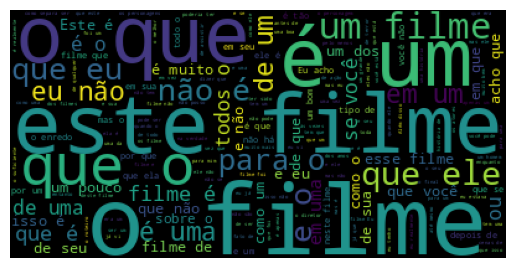

In [28]:
plt.figure()
plt.imshow(word_cloud)
plt.axis('off')
plt.show()

In [29]:
word_cloud = WordCloud(width=800,
                       height=500,
                       max_font_size=110,
                       collocations= False).generate(all_words)

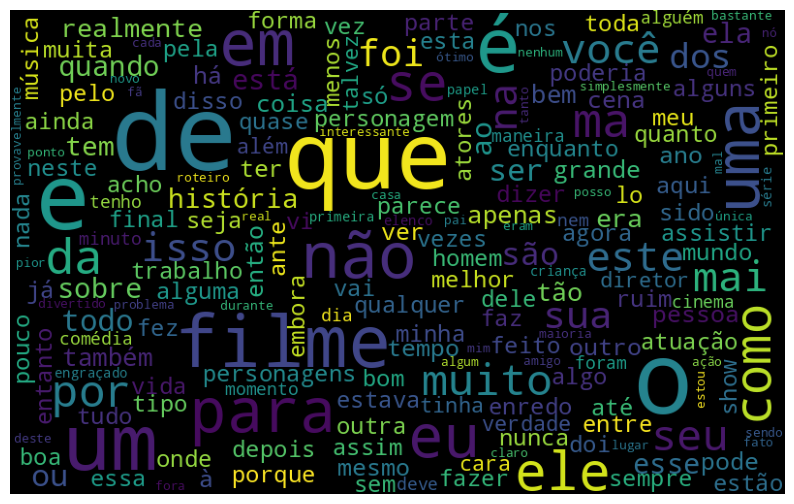

In [30]:
plt.figure(figsize=(10,7))
plt.imshow(word_cloud)
plt.axis('off')
plt.show()

## Positive visual analysis

In [31]:
def word_cloud_neg(texto, coluna_texto):
    texto_negativo = texto.query("sentiment == 'neg'")
    todas_palavras = ' '.join([texto for texto in texto_negativo[coluna_texto]])

    nuvem_palavras = WordCloud(width= 800, height= 500,
                              max_font_size = 110,
                              collocations = False).generate(todas_palavras)
    plt.figure(figsize=(10,7))
    plt.imshow(nuvem_palavras, interpolation='bilinear')
    plt.axis("off")
    plt.show()

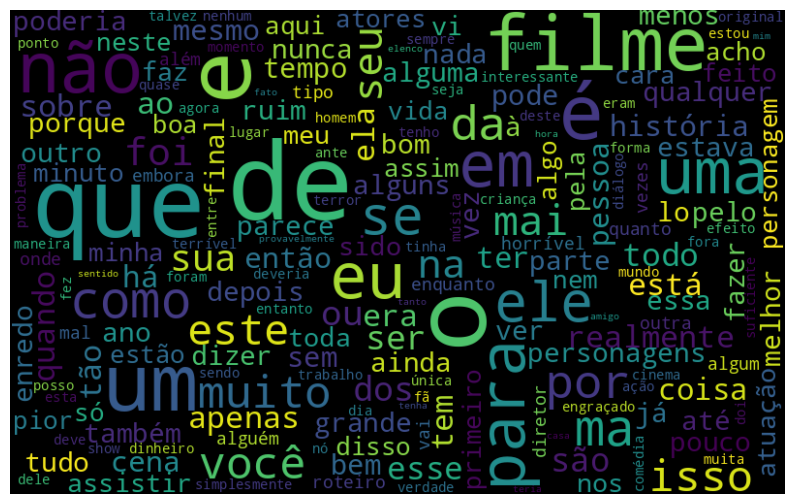

In [32]:
word_cloud_neg(resenha, 'text_pt')

## Negative visual analysis

In [33]:
def word_cloud_pos(texto, coluna_texto):
    positive_text = texto.query("sentiment == 'pos'")
    all_words = ' '.join([texto for texto in positive_text[coluna_texto]])

    word_cloud = WordCloud(width= 800, height= 500,
                              max_font_size = 110,
                              collocations = False).generate(all_words)
    plt.figure(figsize=(10,7))
    plt.imshow(word_cloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

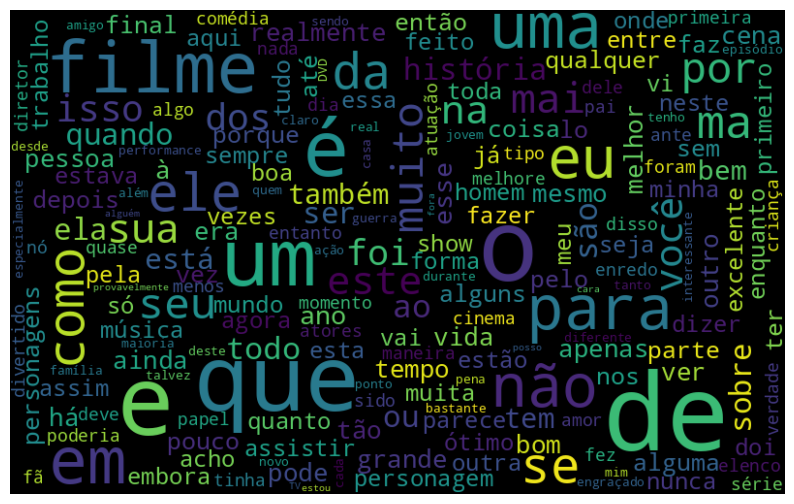

In [34]:
word_cloud_pos(resenha, 'text_pt')

## NLTK library

In [35]:
import nltk

In [36]:
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

True

In [37]:
sentence = ["Um filme ruim", "Um filme bom"]
freq = nltk.FreqDist(sentence)
freq

FreqDist({'Um filme ruim': 1, 'Um filme bom': 1})

Its wrong cause was calculeted the frequency of sentence and not word

### Tokeneize sentences

In [38]:
from nltk import tokenize

In [39]:
sentence = "Welcome to a NPL word"

In [40]:
token_space = tokenize.WhitespaceTokenizer()
token_sentence = token_space.tokenize(sentence)
token_sentence

['Welcome', 'to', 'a', 'NPL', 'word']

### Applying in our case

In [41]:
token_sentence = token_space.tokenize(all_words)
freq = nltk.FreqDist(token_sentence)


In [42]:
freq

FreqDist({'de': 417651, 'que': 325070, 'e': 299743, 'o': 244881, 'um': 216410, 'a': 210179, 'é': 192381, 'em': 132778, 'uma': 130888, 'não': 127915, ...})

In [43]:
df_freq = pd.DataFrame({'Words': list(freq.keys()),
                       'Frequency': list(freq.values())})

In [44]:
df_freq.nlargest(columns = "Frequency", n = 100 )

,Words,Frequency
20,de,417651
14,que,325070
42,e,299743
3,o,244881
7,um,216410
...,...,...
178,faz,11791
759,nunca,11734
428,Mas,11653
464,então,11433


Using a method in pandas to find top 10 most communns words

## Pareto Graph

In [45]:
import seaborn  as sns

def pareto(text, col_text, qtnd):

  all_words = ' '.join([text for text in text[col_text]])
  token_sentence = token_space.tokenize(all_words)
  freq = nltk.FreqDist(token_sentence)
  df_freq = pd.DataFrame({'Words': list(freq.keys()),
                        'Frequency': list(freq.values())})
  df_freq = df_freq.nlargest(columns = "Frequency", n = qtnd)
  plt.figure(figsize=(12,8))
  ax = sns.barplot(data = df_freq, x = 'Words', y = 'Frequency', color = 'gray')
  ax.set(ylabel = 'Frequency')

  plt.show()



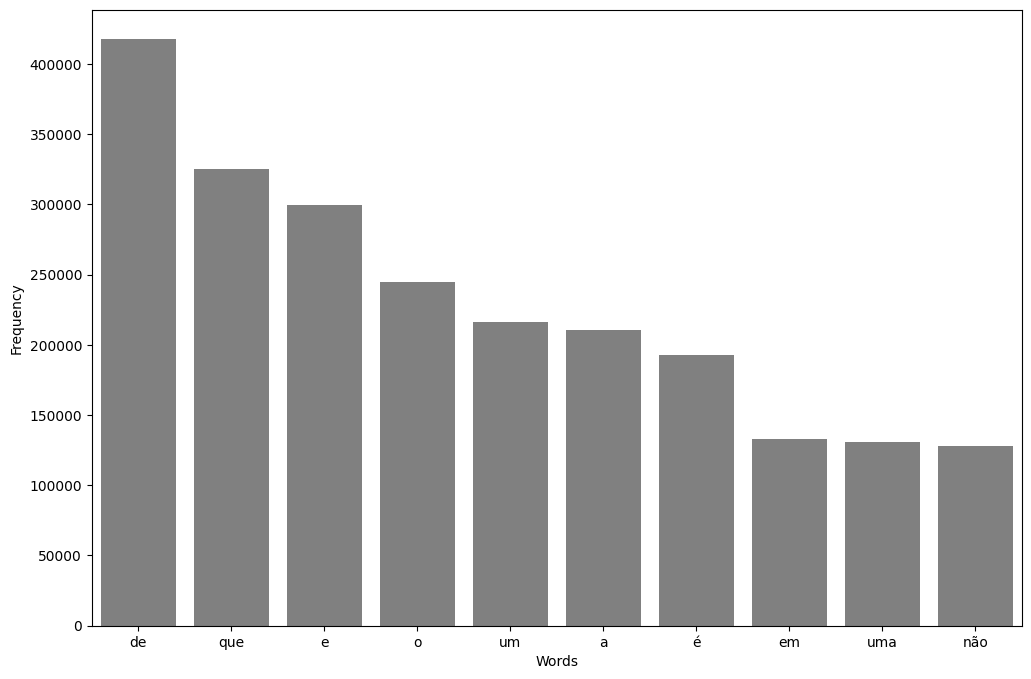

In [46]:
pareto(resenha, 'text_pt', 10)

not usual words we called stop-words

In [47]:
stop_words = nltk.corpus.stopwords.words('portuguese')

In [48]:

sentence_processed = list()
for opiniao in resenha.text_pt:
  new_sentence = []
  word_text = token_space.tokenize(opiniao)
  for palavra in word_text:
    if palavra not in stop_words:
      new_sentence.append(palavra)

  sentence_processed.append(' '.join(new_sentence))

resenha['processed_1'] = sentence_processed


In [54]:
resenha.head()

,id,text_en,text_pt,sentiment,processed_1,classificacao
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg,"Mais vez, Sr. Costner arrumou filme tempo nece...",0
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg,Este exemplo motivo maioria filmes ação mesmos...,0
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg,"Primeiro tudo odeio raps imbecis, poderiam agi...",0
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg,Nem Beatles puderam escrever músicas todos gos...,0
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg,"Filmes fotos latão palavra apropriada eles, ve...",0


In [55]:
classfy_text(resenha, 'processed_1', 'classificacao')

0.6583097452486858

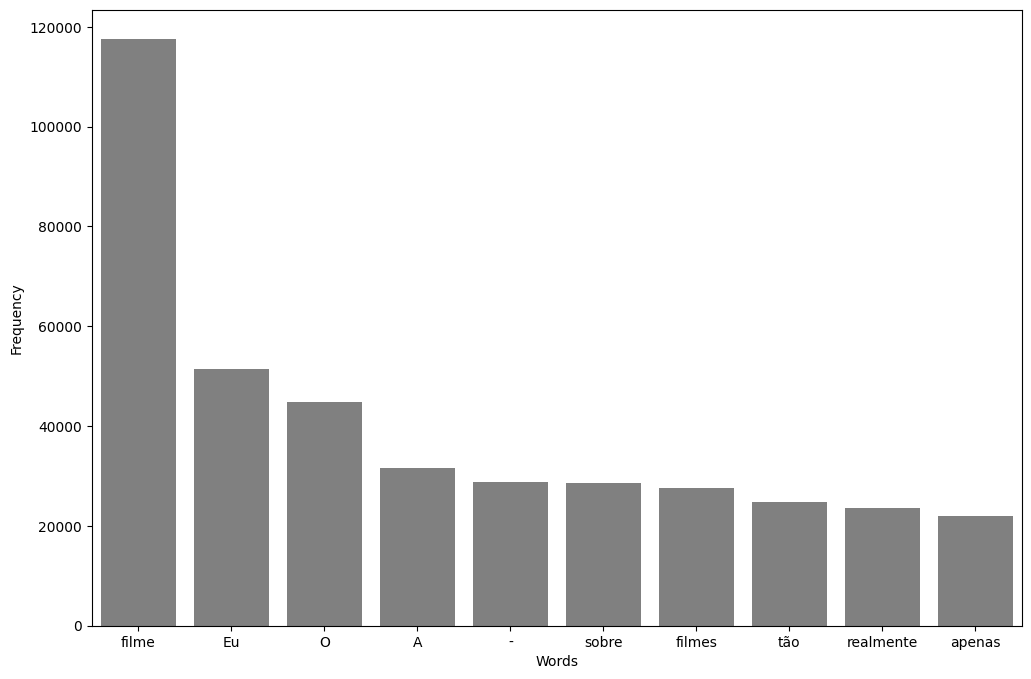

In [56]:
pareto(resenha, 'processed_1',10 )